# 03 — Hyperparameter Tuning and Model Comparison

Loads the logged tuning experiments and the final per-square forecasting
results produced by `scripts/tune_hyperparameters.py` and
`scripts/run_forecasting.py`. Run those scripts first if the tables below
are empty.

In [1]:
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")

import pandas as pd
import yaml
from IPython.display import Image, display

from src.utils import load_config

cfg = load_config("config.yaml")

## 1. Hyperparameter tuning trajectory

In [2]:
tuning_df = pd.read_csv(cfg["paths"]["tuning_results"])
tuning_df

,model,order,fourier_harmonics,rmse,mae,mape,elapsed_s,notes,sequence_length,units,learning_rate,max_depth,n_estimators
0,ARIMA,"[1, 1, 1]",0.0,231.376045,162.864412,13.978145,4.083014,"walk-forward one-step over validation slice, p...",NaN,NaN,NaN,NaN,NaN
1,ARIMA,"[1, 1, 1]",2.0,210.581589,141.980667,12.189376,12.665469,"walk-forward one-step over validation slice, p...",NaN,NaN,NaN,NaN,NaN
2,ARIMA,"[1, 1, 1]",4.0,208.478506,141.239987,12.438728,12.050834,"walk-forward one-step over validation slice, p...",NaN,NaN,NaN,NaN,NaN
3,ARIMA,"[2, 1, 2]",0.0,220.745998,151.336825,12.917772,4.715631,"walk-forward one-step over validation slice, p...",NaN,NaN,NaN,NaN,NaN
4,ARIMA,"[2, 1, 2]",2.0,211.312040,142.076402,12.176369,18.640288,"walk-forward one-step over validation slice, p...",NaN,NaN,NaN,NaN,NaN
5,ARIMA,"[2, 1, 2]",4.0,209.421967,141.243496,12.420276,19.119935,"walk-forward one-step over validation slice, p...",NaN,NaN,NaN,NaN,NaN
6,ARIMA,"[3, 1, 1]",0.0,221.211269,149.885341,12.681406,4.529201,"walk-forward one-step over validation slice, p...",NaN,NaN,NaN,NaN,NaN
7,ARIMA,"[3, 1, 1]",2.0,210.218345,141.064013,12.104282,18.027086,"walk-forward one-step over validation slice, p...",NaN,NaN,NaN,NaN,NaN
8,ARIMA,"[3, 1, 1]",4.0,208.210160,140.185298,12.335755,19.417736,"walk-forward one-step over validation slice, p...",NaN,NaN,NaN,NaN,NaN
9,LSTM,NaN,NaN,247.701861,180.659622,23.246351,5.241474,15 tuning epochs w/ early stopping (patience=3),72.0,[32],0.0010,NaN,NaN


In [3]:
with open("experiments/hyperparameter_tuning/best_params.yaml") as f:
    best_params = yaml.safe_load(f)
best_params

{'arima': {'fourier_harmonics': 4, 'fourier_period': 144, 'order': [3, 1, 1]},
 'lstm': {'learning_rate': 0.001, 'sequence_length': 144, 'units': [64, 32]},
 'tuned_on_square': 5161,
 'validation_window_days': 3,
 'xgboost': {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300}}

## 2. Per-square performance tables (MAE / MAPE / RMSE)

In [4]:
with open(cfg["data"]["target_squares_meta_path"]) as f:
    meta = yaml.safe_load(f)

for sq in meta["top3_squares"]:
    print(f"--- Square {sq} ---")
    display(pd.read_csv(f"results/tables/model_performance_square_{sq}.csv", index_col=0))

--- Square 5161 ---


,MAE,MAPE,RMSE
ARIMA,143.959559,12.249758,222.857456
LSTM,168.734843,21.153433,237.812234
XGBoost,157.879421,12.591513,273.752000


--- Square 5059 ---


,MAE,MAPE,RMSE
ARIMA,124.089507,10.712199,188.133188
LSTM,140.544708,14.882320,199.351886
XGBoost,130.109977,11.304260,191.446587


--- Square 5259 ---


,MAE,MAPE,RMSE
ARIMA,101.813625,9.367653,147.611080
LSTM,109.838305,11.696053,153.679553
XGBoost,98.382932,9.882899,139.682757


## 3. Prediction plots (9 total: 3 squares x 3 models)

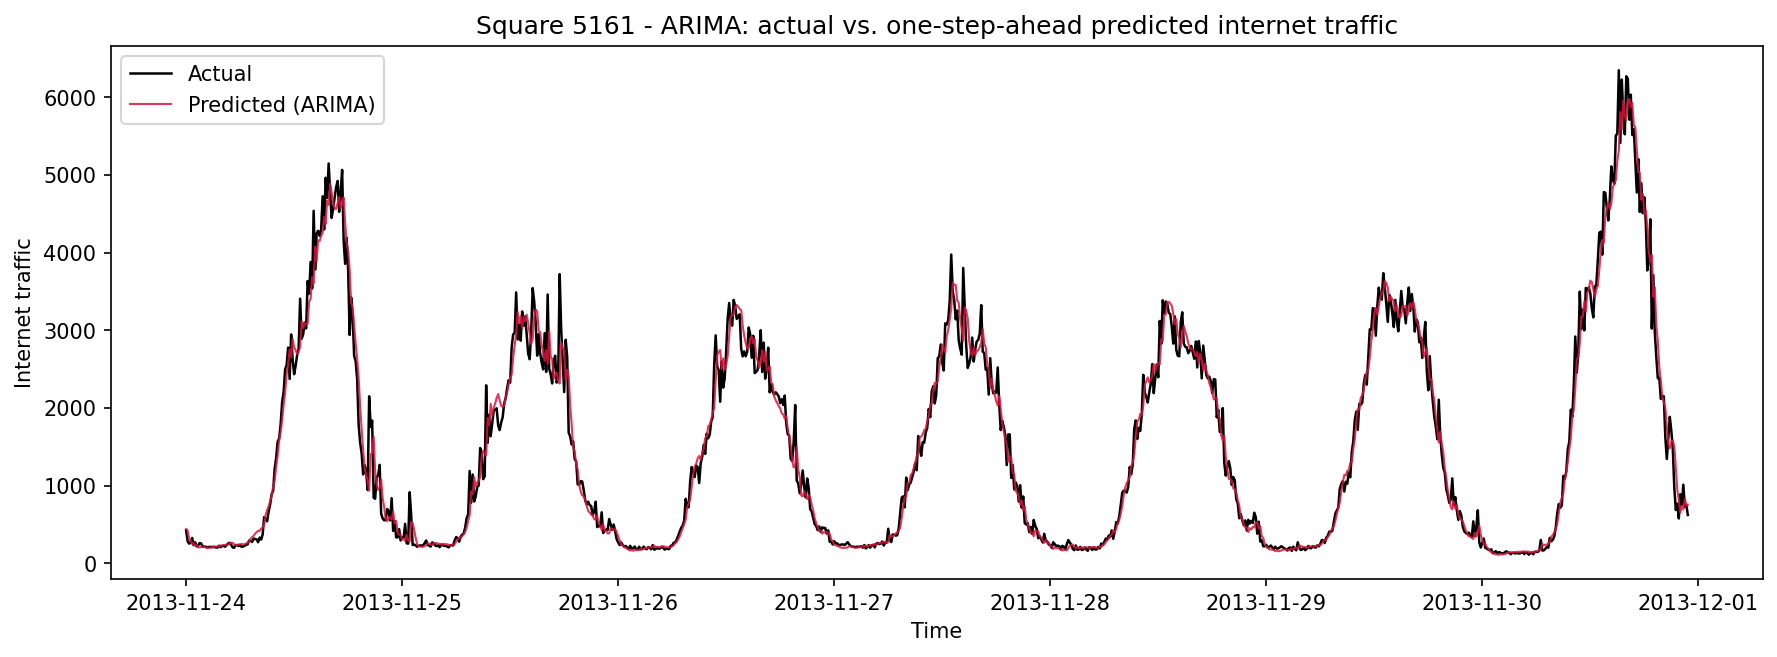

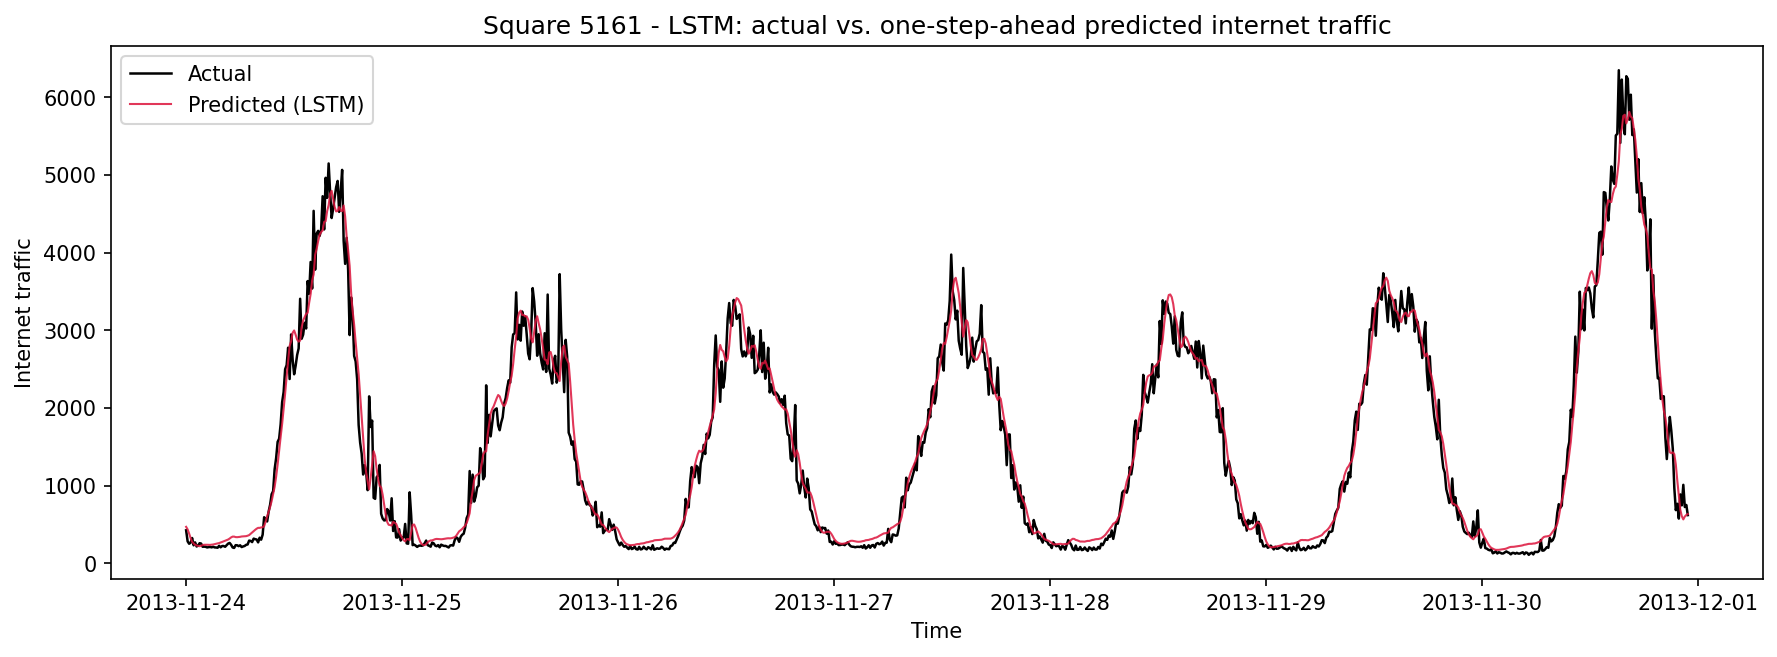

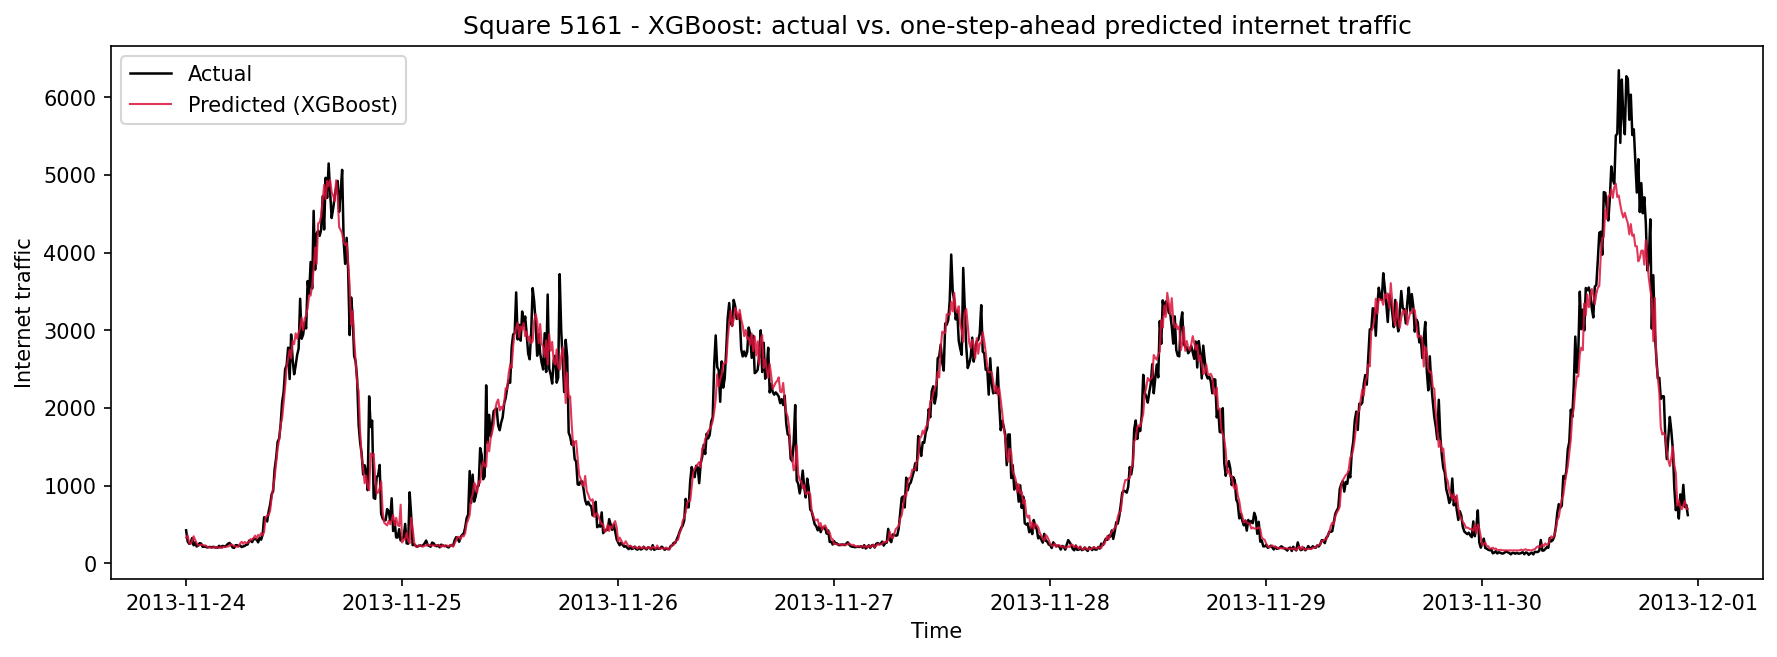

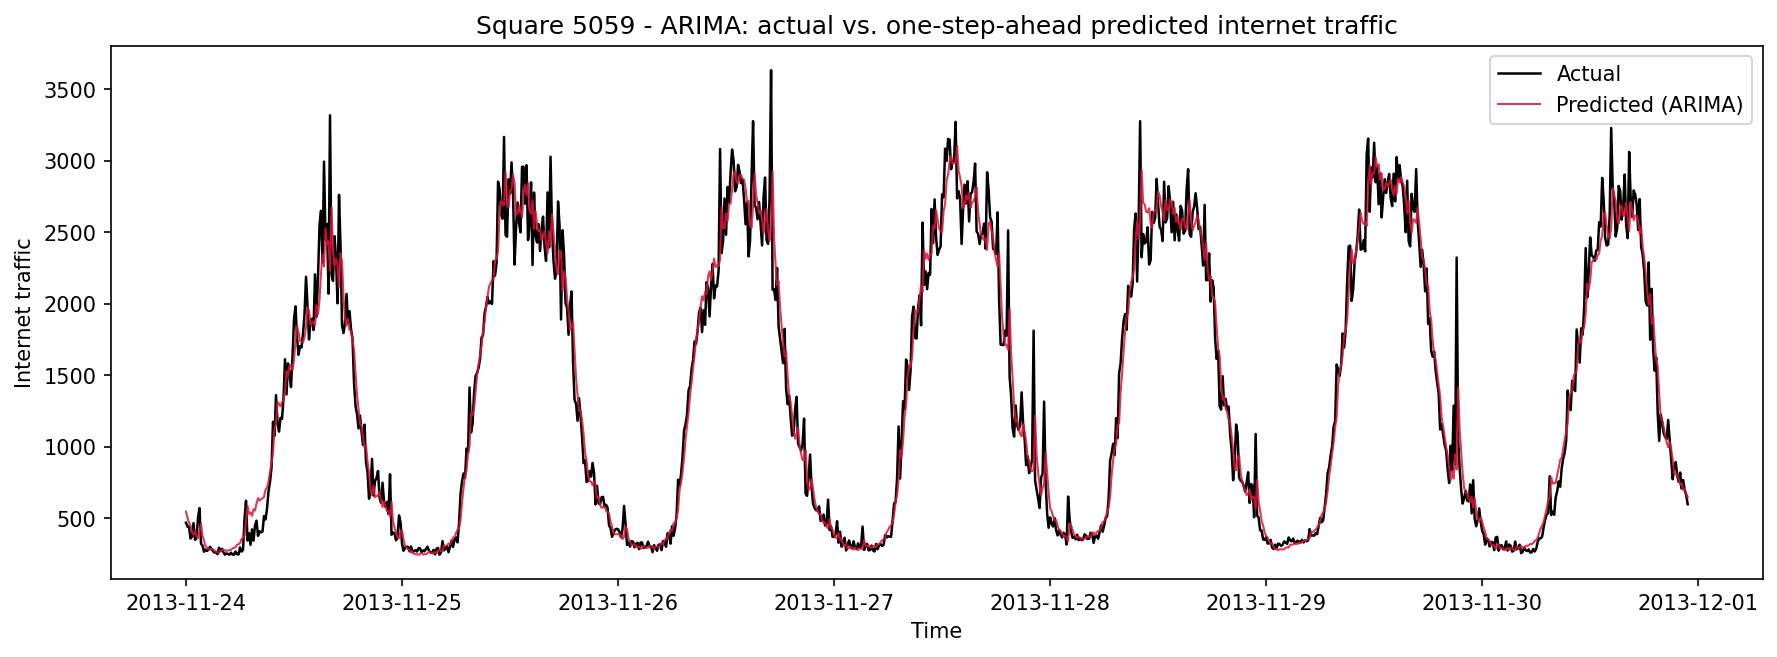

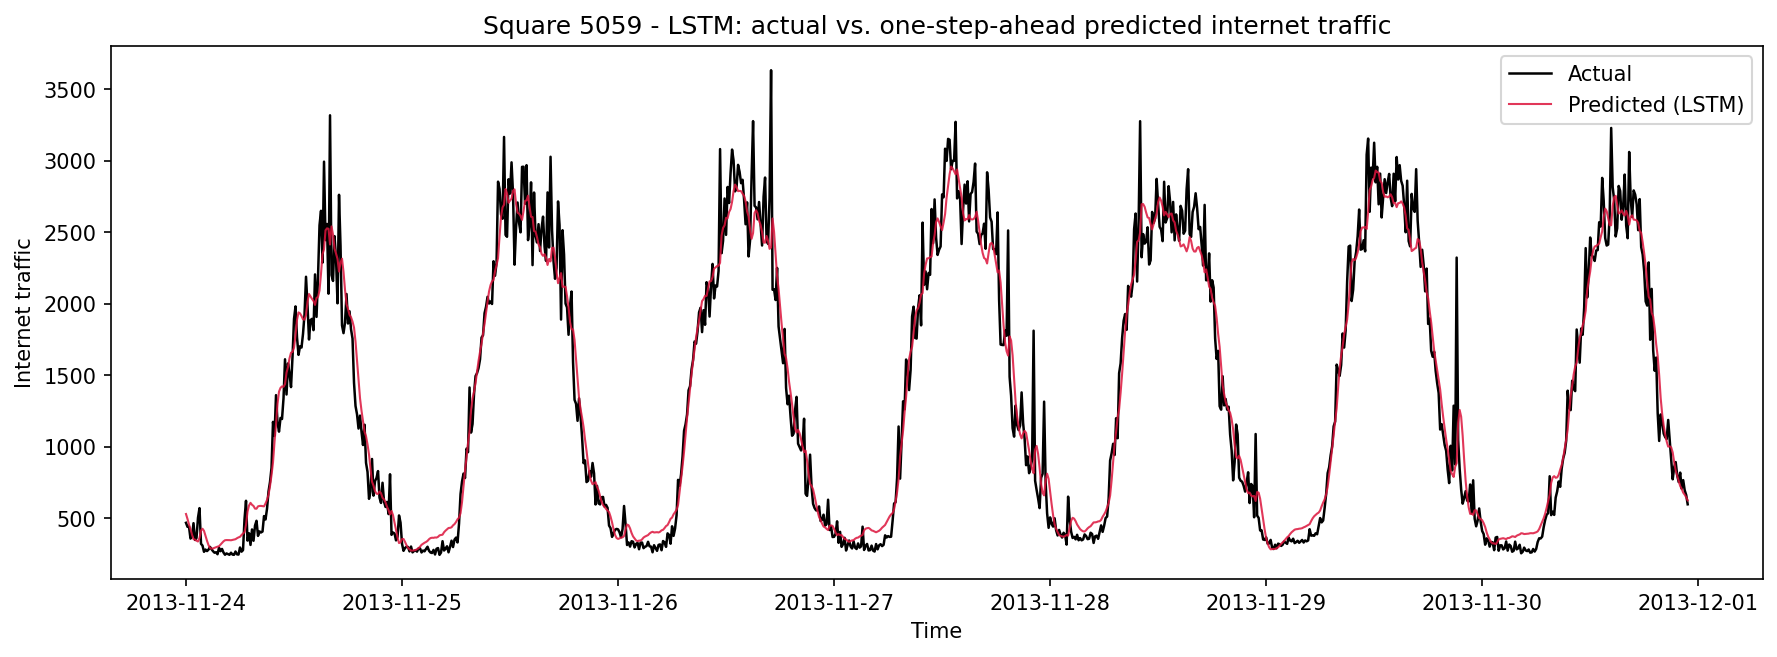

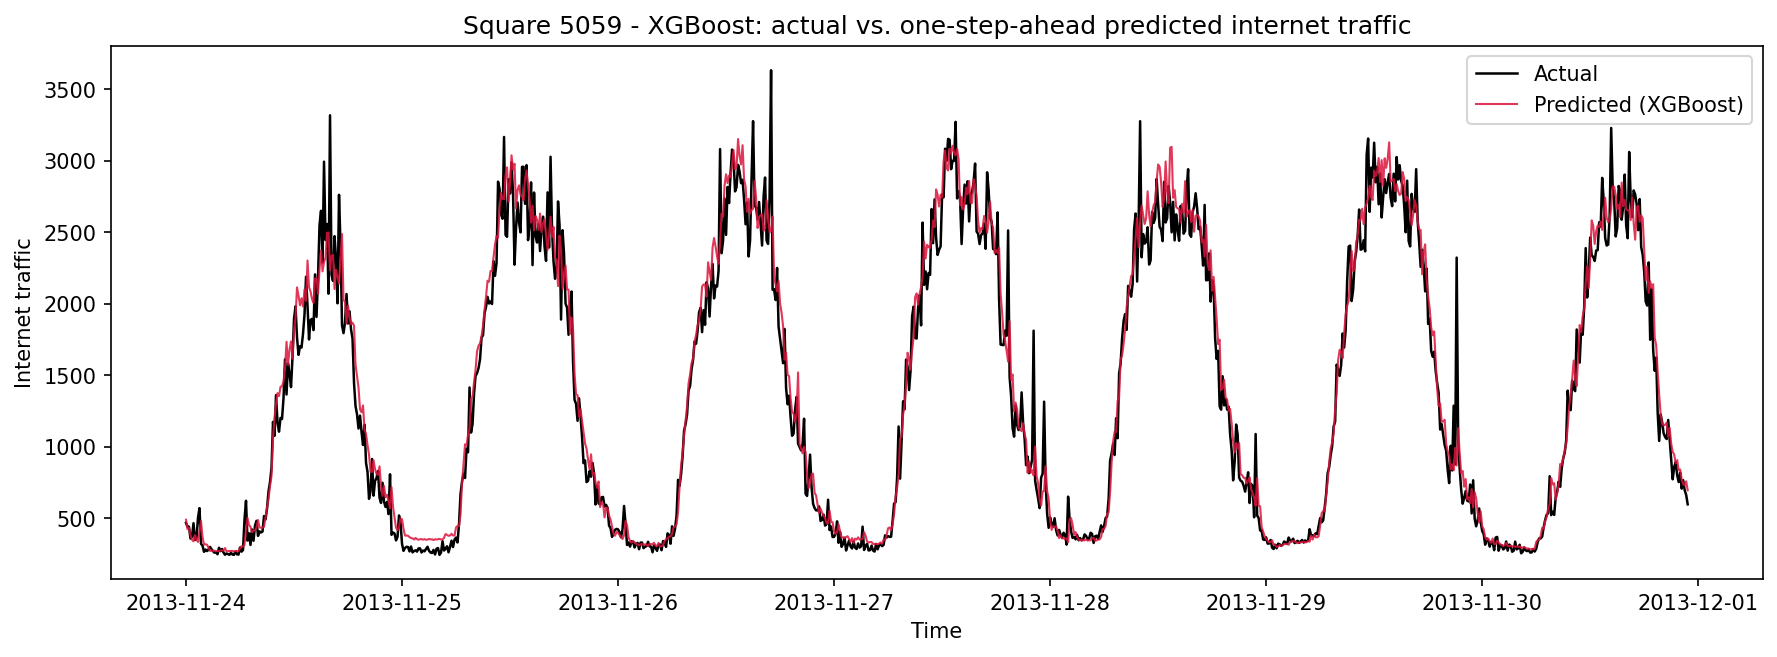

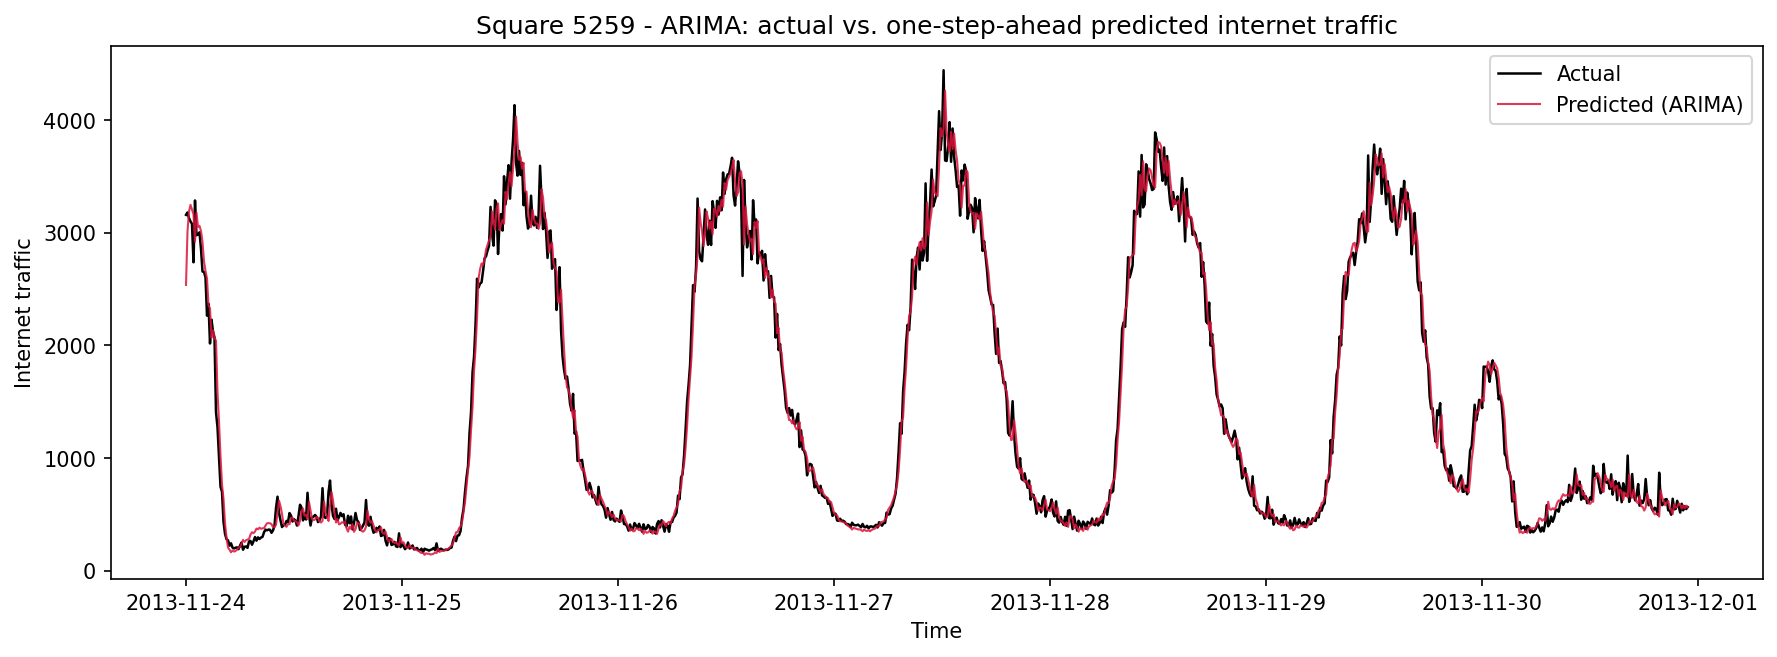

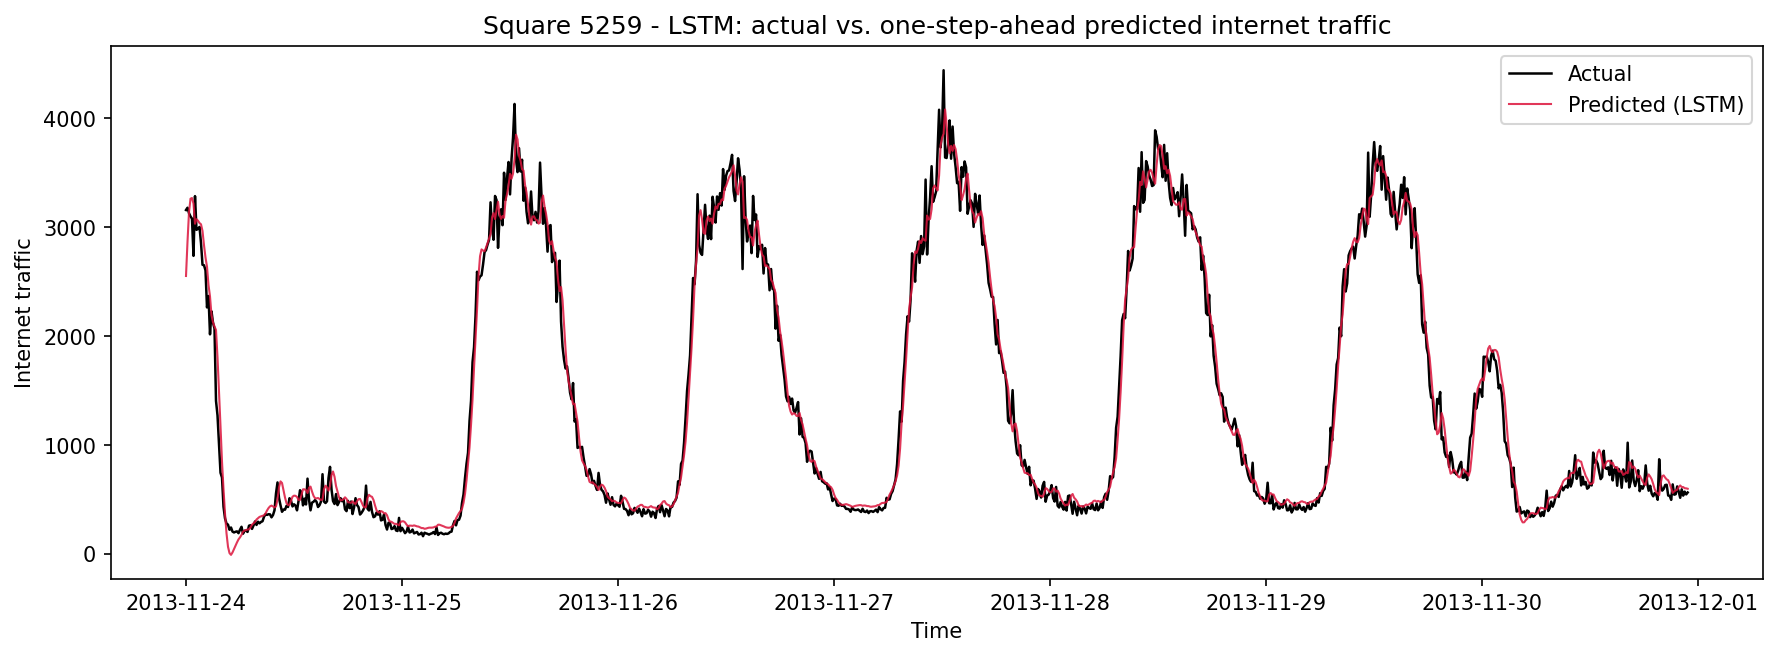

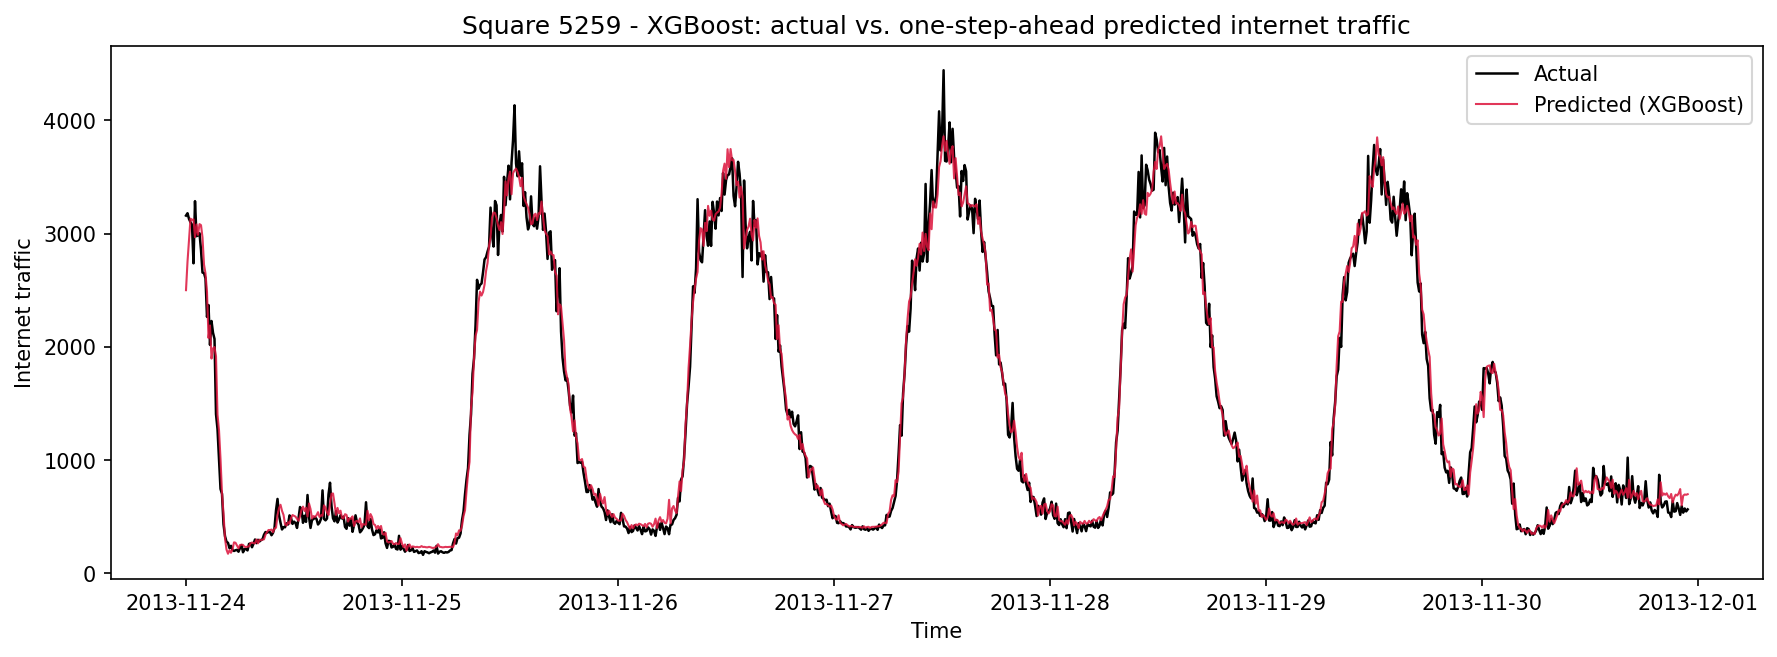

In [5]:
for sq in meta["top3_squares"]:
    for model in ["ARIMA", "LSTM", "XGBoost"]:
        display(Image(filename=f"results/plots/model_predictions/square_{sq}_{model}.png"))

## 4. Timing statistics

In [6]:
pd.read_csv("results/tables/timing_stats.csv")

,square_id,model,fit_time_s,predict_time_total_s,predict_time_per_step_ms
0,5161,ARIMA,2.859892,44.961508,44.871765
1,5161,LSTM,106.655763,0.452422,0.451519
2,5161,XGBoost,0.388467,0.003614,0.003607
3,5059,ARIMA,3.940378,30.481039,30.420198
4,5059,LSTM,106.384760,0.489038,0.488062
5,5059,XGBoost,0.305063,0.005007,0.004997
6,5259,ARIMA,5.426699,30.834806,30.773260
7,5259,LSTM,106.905241,0.693079,0.691695
8,5259,XGBoost,0.310953,0.003933,0.003925


## 5. Cross-square, cross-model comparison

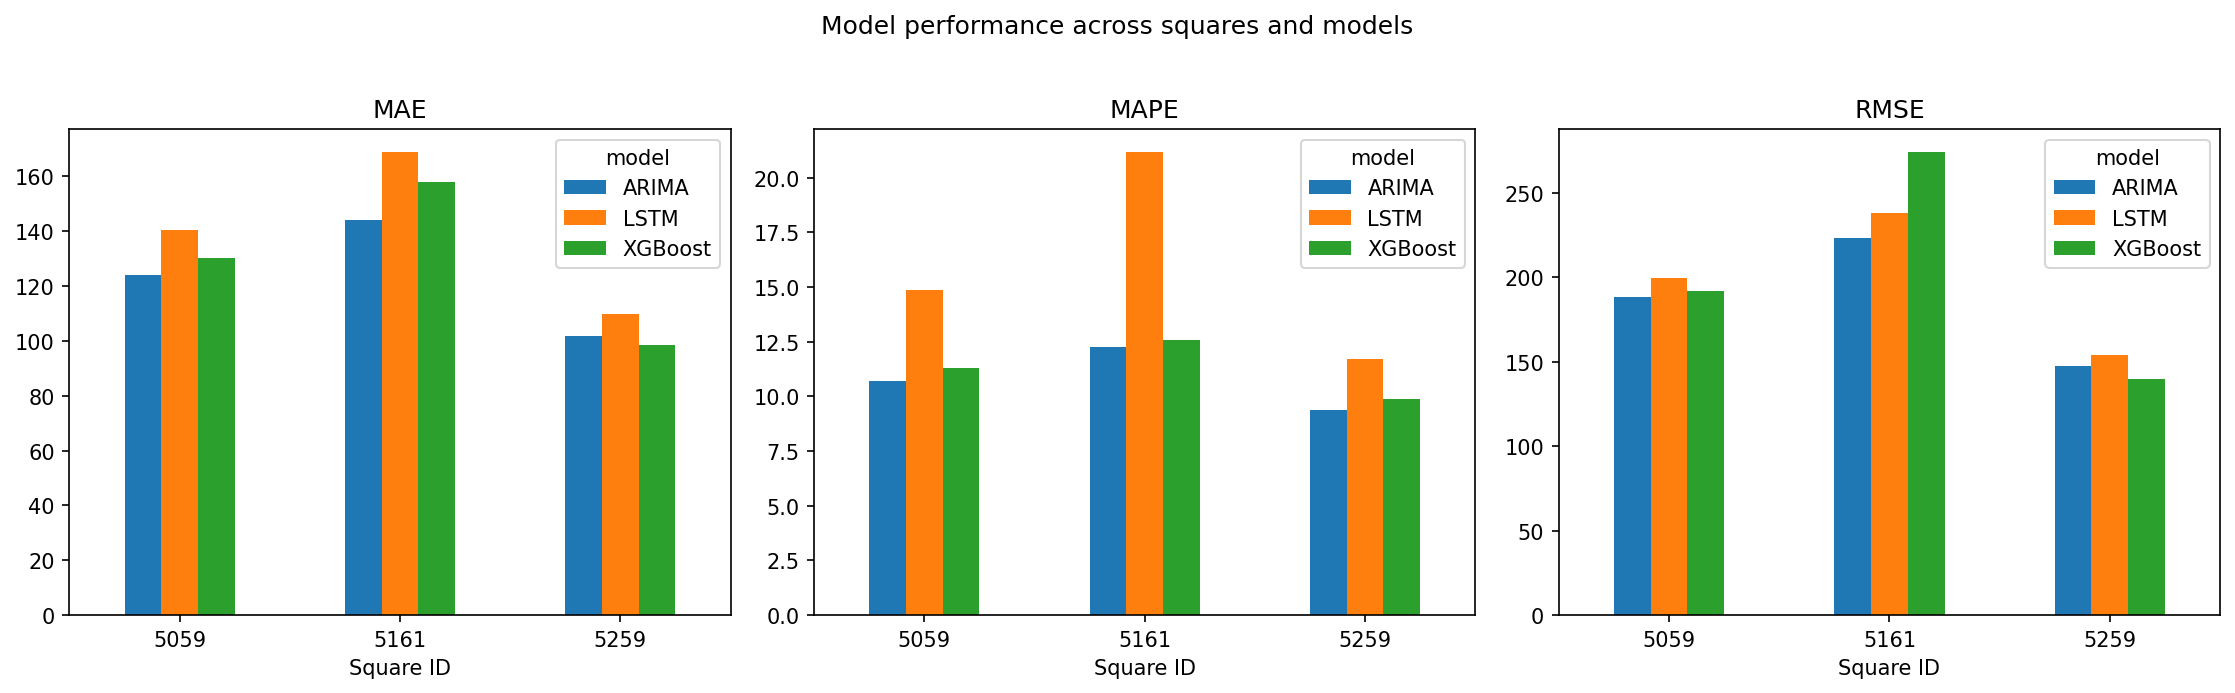

,square_id,model,MAE,RMSE,MAPE,fallback_steps
0,5059,ARIMA,124.089507,188.133188,10.712199,0.0
1,5161,ARIMA,143.959559,222.857456,12.249758,0.0
2,5259,ARIMA,101.813625,147.611080,9.367653,0.0
3,5059,LSTM,140.544708,199.351886,14.882320,NaN
4,5161,LSTM,168.734843,237.812234,21.153433,NaN
5,5259,LSTM,109.838305,153.679553,11.696053,NaN
6,5059,XGBoost,130.109977,191.446587,11.304260,NaN
7,5161,XGBoost,157.879421,273.752000,12.591513,NaN
8,5259,XGBoost,98.382932,139.682757,9.882899,NaN


In [7]:
display(Image(filename="results/plots/comparative_analysis/metric_comparison.png"))
pd.read_csv("results/tables/model_performance_comparison_all.csv")